In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# 1. Load the engineered dataset
print("Step 1: Loading 'Model2_Revenue_Data.csv'...")
df = pd.read_csv('Model2_Revenue_Data.csv')
print(f"Dataset loaded. Total shifts for training: {len(df)}")

Step 1: Loading 'Model2_Revenue_Data.csv'...
Dataset loaded. Total shifts for training: 1623


In [4]:
# 2. Define Features and Target
print("\nStep 2: Defining features and financial target...")
# Note: 'total_cups' is now an INPUT feature for this model
features = ['store_location', 'shift', 'month', 'day_of_week', 'total_cups', 'prev_revenue']
target = 'total_revenue'

X = df[features]
y = df[target]
print(f"Features: {features}")
print(f"Target: {target}")


Step 2: Defining features and financial target...
Features: ['store_location', 'shift', 'month', 'day_of_week', 'total_cups', 'prev_revenue']
Target: total_revenue


In [6]:
# 3. Preprocessing and Model Pipeline
print("\nStep 3: Setting up preprocessing and Random Forest Regressor...")
categorical_features = ['store_location', 'shift', 'day_of_week']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


Step 3: Setting up preprocessing and Random Forest Regressor...


In [8]:
# 4. Split the Data
print("\nStep 4: Splitting data into Training (80%) and Testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Step 4: Splitting data into Training (80%) and Testing (20%) sets...
Training set size: 1298
Testing set size: 325


In [10]:
# 5. Train the Model
print("\nStep 5: Training the Revenue Model...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")


Step 5: Training the Revenue Model...
Training complete.


In [14]:
# 6. Evaluation & Metrics
print("\nStep 6: Calculating performance metrics...")
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print("MODEL 2 REVENUE RESULTS:")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"R-Squared (Accuracy): {r2:.4f}")
print("-" * 30)


Step 6: Calculating performance metrics...
------------------------------
MODEL 2 REVENUE RESULTS:
Mean Absolute Error: $29.71
Root Mean Squared Error: $46.76
R-Squared (Accuracy): 0.9788
------------------------------



Step 7: Generating performance visuals...


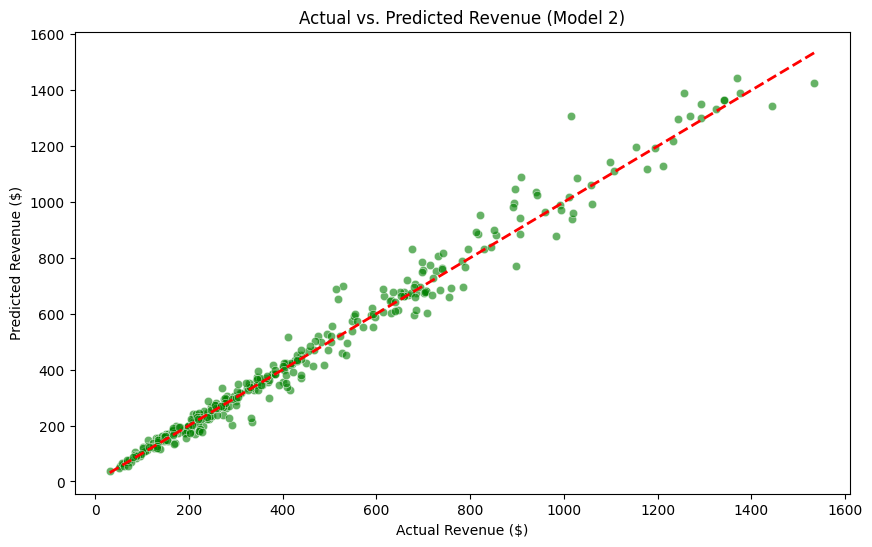

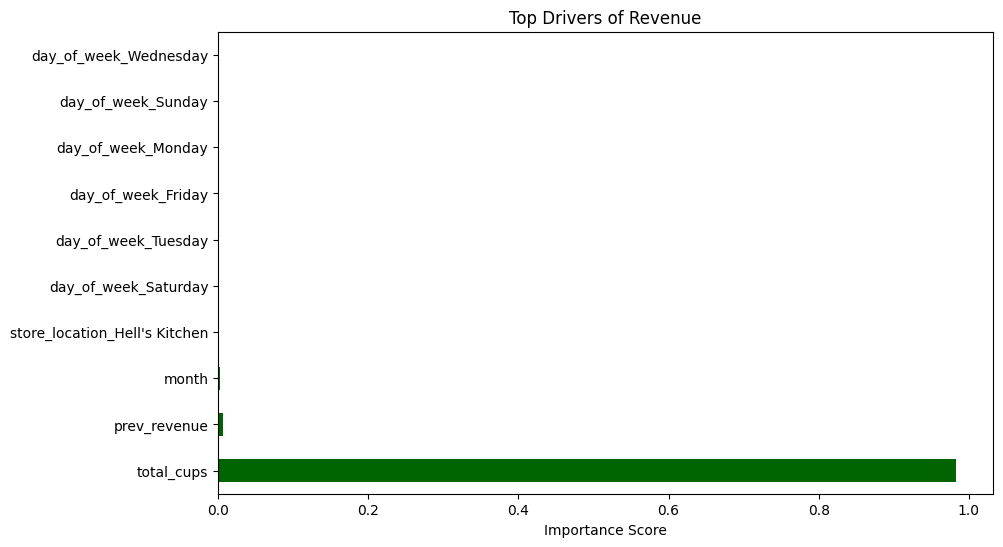

In [15]:
# 7. Visualizations
print("\nStep 7: Generating performance visuals...")

# Plot 1: Actual vs Predicted Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Revenue (Model 2)')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.show()

# Plot 2: Feature Importance
ohe_feature_names = model_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + ['month', 'total_cups', 'prev_revenue']
importances = model_pipeline.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='darkgreen')
plt.title('Top Drivers of Revenue')
plt.xlabel('Importance Score')
plt.show()

In [16]:
# 8. Export the Model
print("\nStep 8: Exporting Revenue Model...")
joblib.dump(model_pipeline, 'model2_revenue_forecast.pkl')
print("Saved as 'model2_revenue_forecast.pkl'.")


Step 8: Exporting Revenue Model...
Saved as 'model2_revenue_forecast.pkl'.
